# Early Warning of Lithium-Ion Thermal Runaway — XGBoost Reproduction Pipeline

**Paper**: Alhasan & Alrashdan (2026), *XGBoost-Powered Predictive Analytics for Early
Identification of Thermal Runaway in Lithium-Ion Batteries*, World Electric Vehicle Journal.

**Scope**: this notebook is the clean final pipeline — running it top to bottom produces the
F1 and SHAP results directly. All exploratory analysis, dead ends and debugging live in
`01_exploration.ipynb`.

**Label**: the paper's definition, `V < 3.0 OR T > 80`, shifted five samples forward.

**Deviation from the paper**: cells whose initial voltage is below 3.0 V are filtered out
before labelling (the paper does not do this).

## 0. Configuration (edit paths here)

In [1]:
import os
from pathlib import Path

# ==== Paths ====
DATA_DIR = Path(os.environ.get(
    'BATTERY_DATA_DIR',
    '/Users/gtw/Desktop/研究生课程/项目记录/新能源/锂电池安全/Mechanically Induced Thermal Runaway for Li-ion Batteries/excel'
))

# Cache directory (avoids re-reading 210 Excel files on every kernel restart)
CACHE_DIR = Path('./cache')
CACHE_DIR.mkdir(exist_ok=True)
RAW_CACHE = CACHE_DIR / 'combined_raw.parquet'

# ==== Experiment settings ====
SEED = 42  # fixed for reproducibility

# Label thresholds
VOLTAGE_THRESHOLD = 3.0     # V, below this -> critical
TEMP_THRESHOLD = 80.0       # °C, above this -> critical
SHIFT_STEPS = 5             # steps the label is shifted forward (paper setting)

# XGBoost hyperparameters (paper §3.5)
XGB_PARAMS = {
    'learning_rate': 0.2,
    'max_depth': 7,
    'n_estimators': 200,
    'random_state': SEED,
    'eval_metric': 'logloss',
}

# Test-set lockbox switch: keep False while training, set True only for final metrics
EVALUATE_TEST = True

## 1. Data loading (cached)

Reading 210 xlsx files takes a few minutes the first time, so the result is cached as parquet.
Subsequent kernel restarts read the parquet in seconds.

The `assert` is fail-fast: a wrong path raises immediately and prints the resolved path,
instead of surfacing as a NameError further downstream.

In [2]:
import pandas as pd
from tqdm.auto import tqdm

# fail-fast: raise immediately if the path is wrong
assert DATA_DIR.exists(), f'Data directory not found: {DATA_DIR.resolve()}'

if RAW_CACHE.exists():
    combined_df = pd.read_parquet(RAW_CACHE)
    print(f'[load] loaded from cache: {combined_df.shape}')
else:
    files = sorted(DATA_DIR.rglob('*.xlsx'))
    assert len(files) > 0, f'No xlsx found under: {DATA_DIR.resolve()}'
    print(f'[load] found {len(files)} files, reading...')

    dfs = []
    failed = []
    for f in tqdm(files, desc='reading'):
        try:
            df = pd.read_excel(f)
            df['file_id'] = f.name
            dfs.append(df)
        except Exception as e:
            failed.append((f.name, str(e)))

    if failed:
        print(f'[load] {len(failed)} files failed to read, first 3: {failed[:3]}')

    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df.to_parquet(RAW_CACHE, index=False)
    print(f'[load] done: {combined_df.shape}, cached to {RAW_CACHE}')

# Sanity check
print(f'Files: {combined_df["file_id"].nunique()}')
print(f'Columns: {list(combined_df.columns)}')

[load] loaded from cache: (3304693, 42)
Files: 209
Columns: ['Time (second)', 'Load (lb)', 'Voltage (V)', 'Unnamed: 3', 'Unnamed: 4', 'Time (sec)', 'Penetrator Force (N)', 'Cell Voltage (V)', 'Displacement (mm)', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Time (sec) ', 'TC1 (°C)', 'TC2 (°C)', 'TC3 (°C)', 'TC4 (°C)', 'file_id', 'Test Time [s]', 'Displacement [mm]', 'Penetrator Force [mm]', 'vCell [V]', 'tAmbient [C]', 'TC1 near positive terminal [C]', 'TC2 near negative terminal [C]', 'TC3 bottom - bottom [C]', 'TC4 bottom - top [C]', 'TC5 above punch [C]', 'TC6 below punch [C]', 'Column1', 'Column2', 'Column3', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26']


## 2. Missing-value handling

Linear interpolation grouped by `file_id` — each cell is handled independently, so the last
row of file A is never interpolated into the first row of file B.

Columns missing more than 90% of their values are dropped rather than imputed.

In [3]:
import numpy as np

# Drop columns missing more than 90% of values
missing_ratio = combined_df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.9].index.tolist()
print(f'Dropping high-missing columns ({len(cols_to_drop)}): {cols_to_drop}')
combined_df = combined_df.drop(columns=cols_to_drop)

# Linear interpolation within each file_id
numeric_cols = combined_df.select_dtypes(include=[np.number]).columns.tolist()
combined_df[numeric_cols] = (
    combined_df.groupby('file_id')[numeric_cols]
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

print(f'After cleaning: {combined_df.shape}')
remaining = combined_df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) > 0:
    print(f'Columns still missing values:\n{remaining}')
else:
    print('No missing values')

Dropping high-missing columns (23): ['Unnamed: 3', 'Unnamed: 4', 'Displacement (mm)', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'TC2 (°C)', 'TC3 (°C)', 'TC4 (°C)', 'tAmbient [C]', 'Column1', 'Column2', 'Column3', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26']
After cleaning: (3304693, 19)
Columns still missing values:
Time (second)                     1489739
Load (lb)                         1489739
Voltage (V)                       1489739
Time (sec)                        1489739
Penetrator Force (N)              1489739
Cell Voltage (V)                  1489739
Time (sec)                        1489739
TC1 (°C)                          1489739
Test Time [s]                     1983473
Displacement [mm]                 1983473
Penetrator Force [mm]             1983473
vCell [V]                         1983473
TC1 near positive terminal [C]    1983473
TC2 near negative terminal [C

## 3. Feature engineering

Four engineered features (paper §4.2):
- `dTC1_dt` = ΔTC/Δt (rate of temperature change)
- `dVoltage_dt` = ΔV/Δt (rate of voltage change)
- `V_F_interaction` = V × F (voltage-force interaction)
- `dT_V_interaction` = dTC/dt × V (temperature-rate-voltage interaction)

> Critical: `diff()` **must** be computed inside `groupby('file_id')`. Otherwise pandas
> subtracts the last row of file A from the first row of file B, producing a
> "cross-cell rate of change" that does not exist — the classic time-series leak.

In [4]:
# Convert Time to numeric, sort by file_id + Time (prerequisite for any time-series operation)
combined_df['Time'] = pd.to_numeric(combined_df['Time (second)'], errors='coerce')
combined_df = combined_df.sort_values(['file_id', 'Time']).reset_index(drop=True)

# Group once, reuse below
g = combined_df.groupby('file_id')

# First derivatives (rates of change)
combined_df['dTC1_dt'] = (
    g['TC1 (°C)'].transform(lambda x: x.diff()) /
    g['Time'].transform(lambda x: x.diff())
)
combined_df['dVoltage_dt'] = (
    g['Voltage (V)'].transform(lambda x: x.diff()) /
    g['Time'].transform(lambda x: x.diff())
)

# Interaction terms
combined_df['V_F_interaction'] = combined_df['Voltage (V)'] * combined_df['Penetrator Force (N)']
combined_df['dT_V_interaction'] = combined_df['dTC1_dt'] * combined_df['Voltage (V)']

# Fill zeros only on the engineered columns.
# Never on the raw physical columns - a fabricated "0 V" or "0 °C" would be learned as real signal.
new_feature_cols = ['dTC1_dt', 'dVoltage_dt', 'V_F_interaction', 'dT_V_interaction']
combined_df[new_feature_cols] = combined_df[new_feature_cols].fillna(0)

print(f'After feature engineering: {combined_df.shape}')
print(f'New column statistics:\n{combined_df[new_feature_cols].describe().T[["mean", "std", "min", "max"]]}')

After feature engineering: (3304693, 24)
New column statistics:
                        mean          std           min         max
dTC1_dt                  NaN          NaN          -inf         inf
dVoltage_dt              NaN          NaN          -inf         inf
V_F_interaction  -463.274284  1274.554042 -2.580152e+04  585.270276
dT_V_interaction         NaN          NaN          -inf         inf


/opt/anaconda3/envs/environment_BU520750/lib/python3.11/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/anaconda3/envs/environment_BU520750/lib/python3.11/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/anaconda3/envs/environment_BU520750/lib/python3.11/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


### 3.1 Visual check of one cell

Before any filtering or labelling, plot the raw signals and the four engineered features for a
single test, so the physical event behind the numbers is visible.

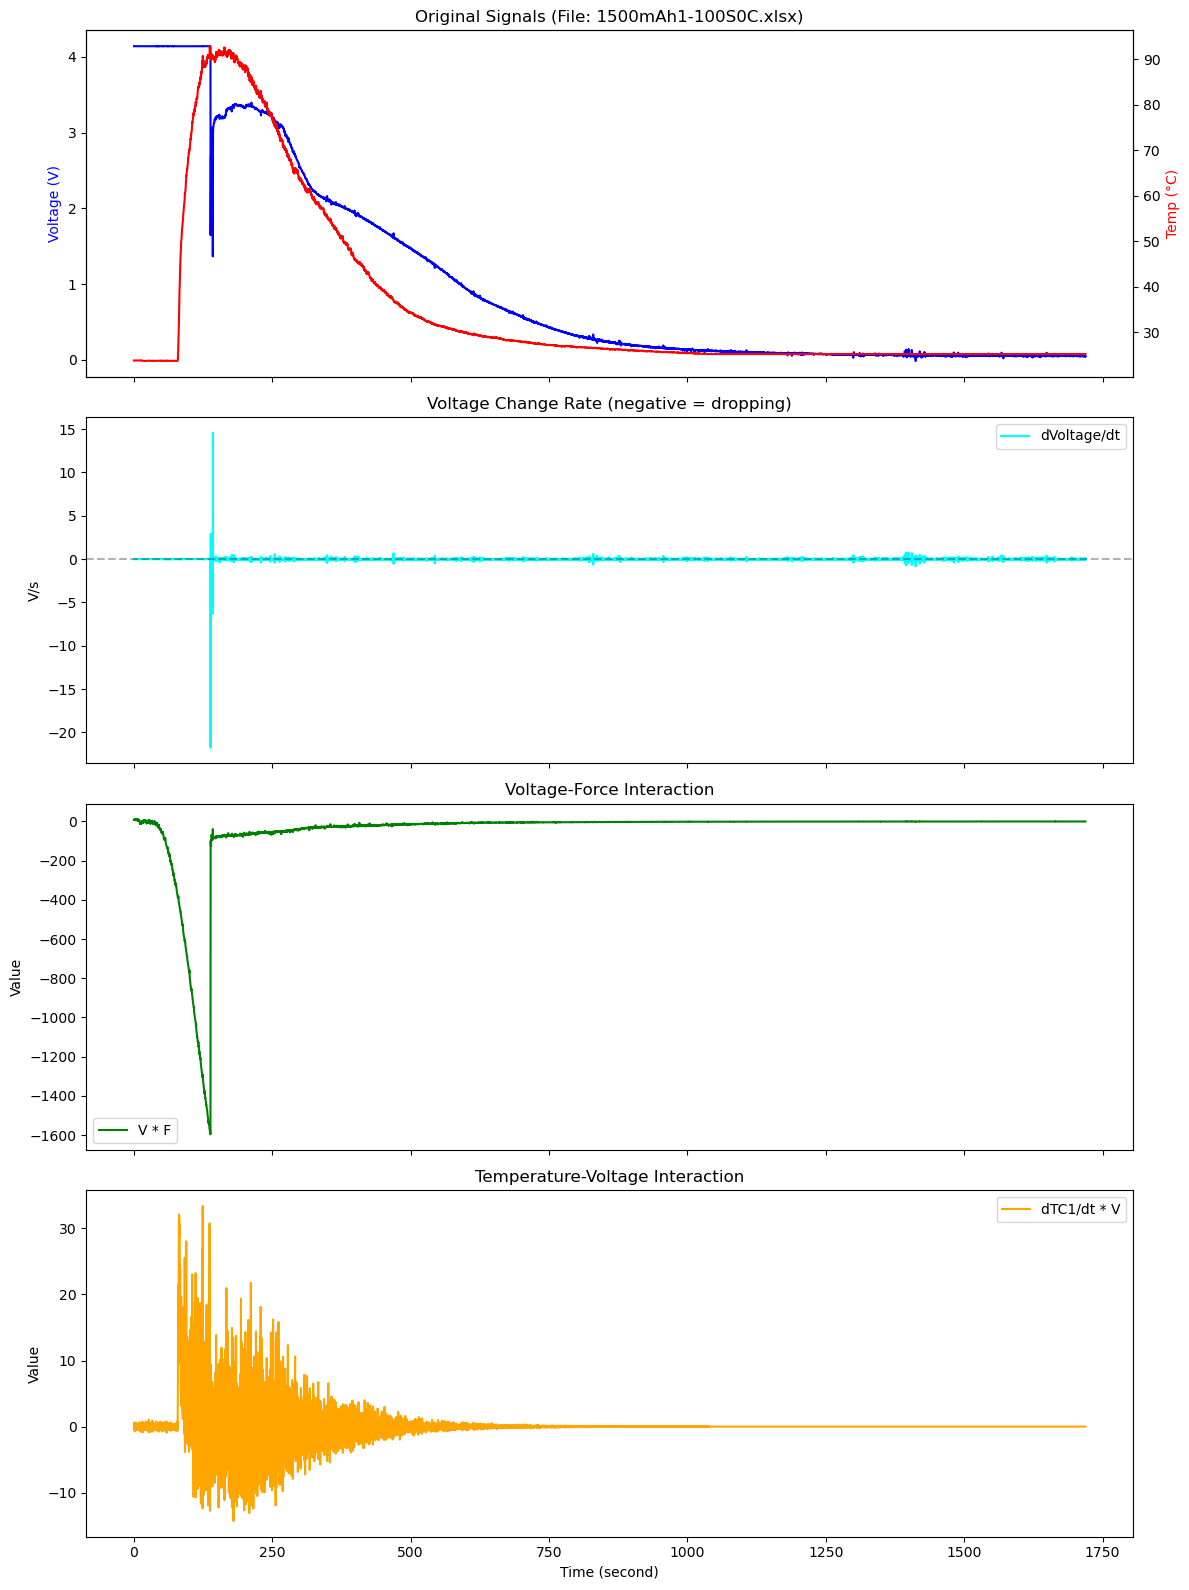

In [5]:
import matplotlib.pyplot as plt

# One representative test
sample_id = combined_df['file_id'].iloc[0]
plot_df = combined_df[combined_df['file_id'] == sample_id].copy()

# Local copy only: ±inf in the derivative columns would blow up the y-axis.
# This does not alter the pipeline - combined_df is untouched.
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

# 1. Raw voltage and temperature, two y-axes on a shared time axis
ax1_twin = axes[0].twinx()
axes[0].plot(plot_df['Time'], plot_df['Voltage (V)'], color='blue', label='Voltage (V)')
ax1_twin.plot(plot_df['Time'], plot_df['TC1 (°C)'], color='red', label='Temp (°C)')
axes[0].set_ylabel('Voltage (V)', color='blue')
ax1_twin.set_ylabel('Temp (°C)', color='red')
axes[0].set_title(f'Original Signals (File: {sample_id})')

# 2. Rate of voltage change
axes[1].plot(plot_df['Time'], plot_df['dVoltage_dt'], color='cyan', label='dVoltage/dt')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].set_ylabel('V/s')
axes[1].set_title('Voltage Change Rate (negative = dropping)')
axes[1].legend()

# 3. Voltage-force interaction
axes[2].plot(plot_df['Time'], plot_df['V_F_interaction'], color='green', label='V * F')
axes[2].set_ylabel('Value')
axes[2].set_title('Voltage-Force Interaction')
axes[2].legend()

# 4. Temperature-rate / voltage interaction
axes[3].plot(plot_df['Time'], plot_df['dT_V_interaction'], color='orange', label='dTC1/dt * V')
axes[3].set_ylabel('Value')
axes[3].set_xlabel('Time (second)')
axes[3].set_title('Temperature-Voltage Interaction')
axes[3].legend()

plt.tight_layout()
plt.savefig('feature_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data quality control: filtering by initial voltage

The paper does not do this. The criterion here is to keep only files whose **initial voltage is
at least 3.0 V**. A cell that already sits in a low-voltage state is not a sample of a healthy
cell entering runaway, and including it changes what the label means.

Three steps: describe, filter, then describe again to confirm the effect.

In [6]:
# Step 1: initial voltage per file
file_init = combined_df.groupby('file_id')['Voltage (V)'].first()
init_low = (file_init < VOLTAGE_THRESHOLD).sum()
print(f'Files with initial voltage < {VOLTAGE_THRESHOLD}V: {init_low}/{len(file_init)} ({init_low/len(file_init):.1%})')

# Step 2: filter
healthy_files = file_init[file_init >= VOLTAGE_THRESHOLD].index
combined_df = combined_df[combined_df['file_id'].isin(healthy_files)].copy()

# Step 3: confirm the effect
print(f'Remaining after filter: {combined_df["file_id"].nunique()} files, {len(combined_df):,} rows')

Files with initial voltage < 3.0V: 0/209 (0.0%)
Remaining after filter: 132 files, 1,814,954 rows


## 5. Label construction

The paper's definition:

```
Critical = (V < 3.0) OR (T > 80)
```

Both conditions are thresholds on a *level*, so a cell that has already collapsed stays
labelled critical for as long as it remains below 3.0 V. That is what produces the
near-balanced class distribution the paper reports (45% critical).

`shift(-N)` moves the label forward by N steps so the model learns "critical will occur N steps
from now". This **must** be grouped by file, or the last rows of file A are filled with the
opening rows of file B.

Note that N counts *samples*, not seconds. Sampling intervals in this dataset vary from 0.045 s
upward, so five samples is a different duration in every file.

In [7]:
combined_df['Critical_Raw'] = (
    (combined_df['Voltage (V)'] < VOLTAGE_THRESHOLD) |
    (combined_df['TC1 (°C)'] > TEMP_THRESHOLD)
).astype(int)

# Shift forward, grouped by file_id to prevent cross-file contamination
combined_df['Critical_Shifted'] = (
    combined_df.groupby('file_id')['Critical_Raw'].shift(-SHIFT_STEPS)
)

# The last N rows of each file have no future, so Critical_Shifted is NaN - drop them
combined_df = combined_df.dropna(subset=['Critical_Shifted']).copy()
combined_df['Critical_Shifted'] = combined_df['Critical_Shifted'].astype(int)

# Label distribution
counts = combined_df['Critical_Shifted'].value_counts()
print('Label: paper (V<3.0 | T>80)')
print(f'  Normal   (0): {counts[0]:>10,} ({counts[0]/len(combined_df):.1%})')
print(f'  Critical (1): {counts[1]:>10,} ({counts[1]/len(combined_df):.1%})')

Label: paper (V<3.0 | T>80)
  Normal   (0):  1,081,853 (59.6%)
  Critical (1):    732,441 (40.4%)


In [8]:
# Which branch of the label fires, and how often
temp_trigger = (combined_df['TC1 (°C)'] > TEMP_THRESHOLD).sum()
volt_trigger = (combined_df['Voltage (V)'] < VOLTAGE_THRESHOLD).sum()

print(f'Rows over the temperature threshold (TC1 > {TEMP_THRESHOLD}): {temp_trigger:>10,}')
print(f'Rows under the voltage threshold (V < {VOLTAGE_THRESHOLD}):     {volt_trigger:>10,}')
print(f'Total rows: {len(combined_df):,}')

# TC1 is used by the label but is not among FEATURE_COLS below - only its rate of change is.
# Events driven purely by the temperature branch therefore have no corresponding input feature.
print(f'Temperature branch as a share of all threshold crossings: '
      f'{temp_trigger / (temp_trigger + volt_trigger):.1%}')

Rows over the temperature threshold (TC1 > 80.0):    118,034
Rows under the voltage threshold (V < 3.0):        637,037
Total rows: 1,814,294
Temperature branch as a share of all threshold crossings: 15.6%


## 6. Train / test split (file-level)

**`sklearn.train_test_split` must not be used here** — it splits by row, so data from the same
cell lands in both train and test, which lets the model see the answers in advance.

The correct approach assigns whole `file_id`s: the train and test file sets are disjoint.

In [9]:
# File-level shuffle (whole files, to prevent temporal leakage)
all_files = combined_df['file_id'].unique()
rng = np.random.default_rng(SEED)
all_files_shuffled = rng.permutation(all_files)

train_size = int(len(all_files_shuffled) * 0.8)
train_ids = all_files_shuffled[:train_size]
test_ids = all_files_shuffled[train_size:]

# Sanity check: no overlap
assert len(set(train_ids) & set(test_ids)) == 0, 'train/test files overlap!'

train_df = combined_df[combined_df['file_id'].isin(train_ids)].copy()
test_df = combined_df[combined_df['file_id'].isin(test_ids)].copy()

print(f'Train: {len(train_ids):>3} files, {len(train_df):>10,} rows')
print(f'Test:  {len(test_ids):>3} files, {len(test_df):>10,} rows')

Train: 105 files,  1,417,479 rows
Test:   27 files,    396,815 rows


## 7. Building X / Y

`clean_features` handles three things:
1. `inf` / `-inf` → `NaN` → `0` (extreme values produced by division by zero)
2. Clipping of extreme magnitudes (guards against XGBoost numerical instability)
3. Leaves the original `df` untouched (isolated via `.copy()`)

In [10]:
FEATURE_COLS = [
    'Voltage (V)', 'dVoltage_dt',
    'Penetrator Force (N)', 'dTC1_dt',
    'V_F_interaction', 'dT_V_interaction'
]

def clean_features(df, cols):
    """Clean the feature matrix: handle inf/nan/extreme values. Does not modify df."""
    X = df[cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    X = X.clip(lower=-1e10, upper=1e10)
    return X

X_train = clean_features(train_df, FEATURE_COLS)
Y_train = train_df['Critical_Shifted']

X_test = clean_features(test_df, FEATURE_COLS)
Y_test = test_df['Critical_Shifted']

print(f'X_train: {X_train.shape}, Y_train: {Y_train.shape}')
print(f'X_test:  {X_test.shape}, Y_test:  {Y_test.shape}')
print(f'\nTrain labels: {Y_train.value_counts().to_dict()}')
print(f'Test labels:  {Y_test.value_counts().to_dict()}')

X_train: (1417479, 6), Y_train: (1417479,)
X_test:  (396815, 6), Y_test:  (396815,)

Train labels: {0: 870325, 1: 547154}
Test labels:  {0: 211528, 1: 185287}


## 8. Training XGBoost

Hyperparameters from paper §3.5. Training time is printed because it matters for deployment.

In [11]:
import xgboost as xgb
import time

print('Training XGBoost...')
t0 = time.time()

model = xgb.XGBClassifier(**XGB_PARAMS)
model.fit(X_train, Y_train)

print(f'Training time: {time.time()-t0:.1f} s')
print(f'Model size: {model.n_estimators} trees, max_depth={model.max_depth}')

Training XGBoost...
Training time: 2.1 s
Model size: 200 trees, max_depth=7


## 9. Test-set evaluation (F1 / Precision / Recall)

**The `EVALUATE_TEST` switch**: keep it `False` while tuning so the test set stays sealed; set it
`True` once, for the final numbers, and do not tune the model afterwards.

Metrics reported in the paper's Table 2: Precision = 0.99, Recall = 0.98, **F1 = 0.98**

=== Test Set Performance ===

              precision    recall  f1-score   support

      Normal      0.932     0.977     0.954    211528
    Critical      0.972     0.918     0.944    185287

    accuracy                          0.950    396815
   macro avg      0.952     0.948     0.949    396815
weighted avg      0.951     0.950     0.949    396815

F1 (Critical class): 0.944   [paper reports 0.98]


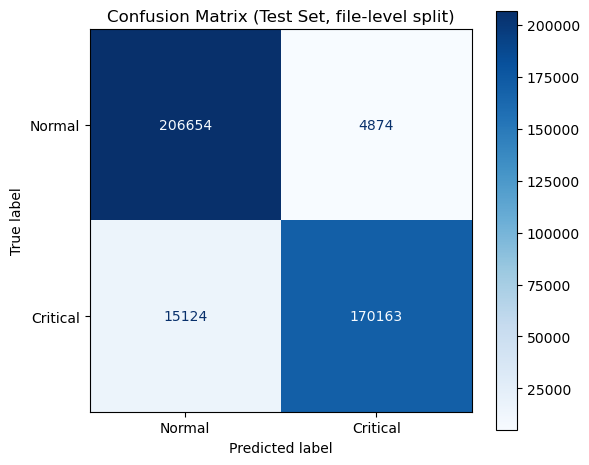

In [12]:
if EVALUATE_TEST:
    from sklearn.metrics import (
        classification_report, confusion_matrix, f1_score,
        ConfusionMatrixDisplay
    )
    import matplotlib.pyplot as plt

    # Predict
    Y_pred = model.predict(X_test)
    Y_proba = model.predict_proba(X_test)[:, 1]  # kept for SHAP / PR curves

    # Core metrics from the paper's Table 2
    print('=== Test Set Performance ===\n')
    print(classification_report(
        Y_test, Y_pred,
        target_names=['Normal', 'Critical'],
        digits=3
    ))

    f1 = f1_score(Y_test, Y_pred)
    print(f'F1 (Critical class): {f1:.3f}   [paper reports 0.98]')

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(Y_test, Y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal', 'Critical']
    )
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title('Confusion Matrix (Test Set, file-level split)')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('EVALUATE_TEST = False, test set is sealed.')
    print('Once training is satisfactory, set EVALUATE_TEST = True in the config cell and re-run.')

## 10. SHAP interpretation (paper Figures 3-5)

SHAP decomposes each prediction into the contribution of every feature, and is the de facto
standard for interpretability.

`TreeExplainer` is used because it is specific to tree models: exact rather than approximate,
and much faster.

SHAP values are computed on a 5,000-row subsample rather than the full test set: the full run
takes over ten minutes and a subsample gives an almost identical global explanation. The paper
does the same.

Computing SHAP values (n=5000)...
Elapsed: 0.7 s


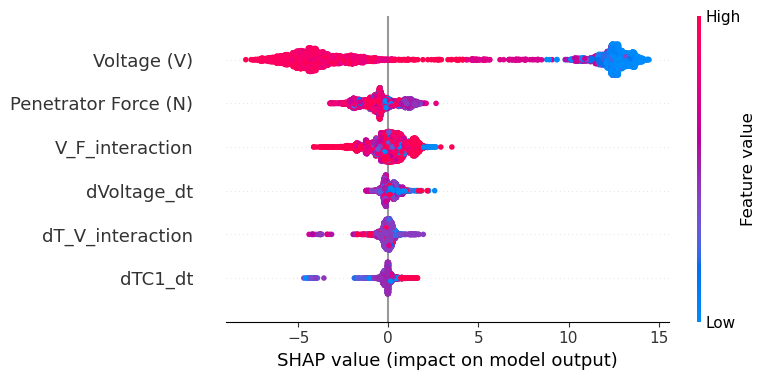

<Figure size 640x480 with 0 Axes>

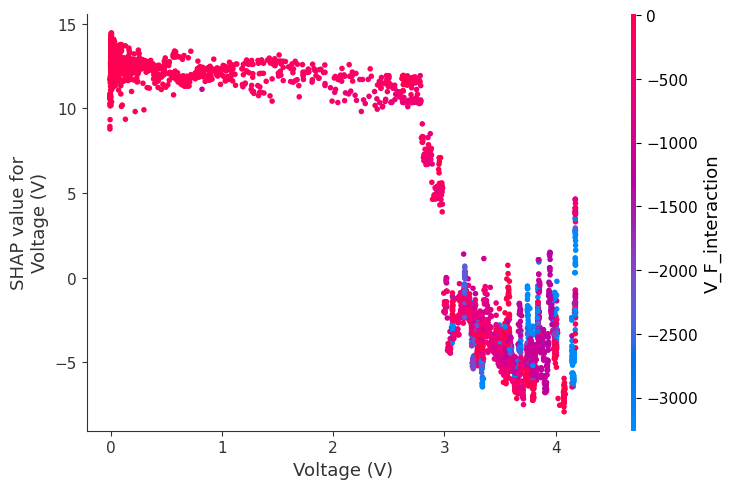

<Figure size 640x480 with 0 Axes>

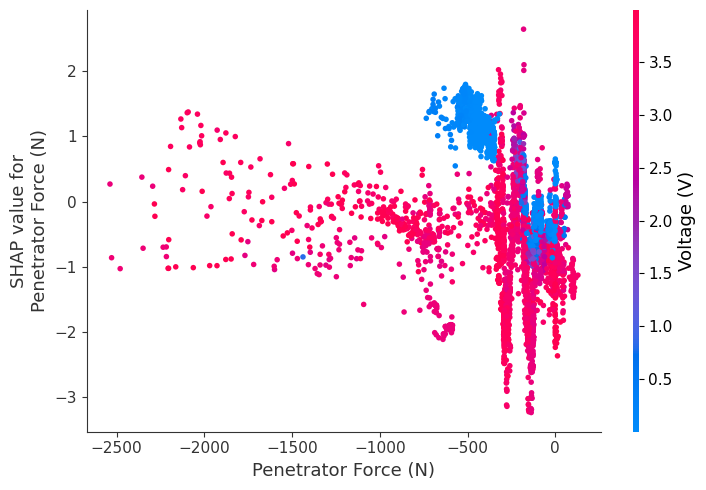

In [13]:
if EVALUATE_TEST:
    import shap
    import matplotlib.pyplot as plt

    explainer = shap.TreeExplainer(model)

    # Subsample
    sample_size = min(5000, len(X_test))
    X_sample = X_test.sample(n=sample_size, random_state=SEED)

    print(f'Computing SHAP values (n={sample_size})...')
    t0 = time.time()
    shap_values = explainer.shap_values(X_sample)
    print(f'Elapsed: {time.time()-t0:.1f} s')

    # === Paper Figure 3: summary plot (global feature importance) ===
    plt.figure()
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    # === Paper Figure 4: dependence plot for Voltage ===
    plt.figure()
    shap.dependence_plot(
        'Voltage (V)', shap_values, X_sample,
        feature_names=FEATURE_COLS, show=False
    )
    plt.tight_layout()
    plt.savefig('shap_voltage_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()

    # === Paper Figure 5: dependence plot for Force ===
    plt.figure()
    shap.dependence_plot(
        'Penetrator Force (N)', shap_values, X_sample,
        feature_names=FEATURE_COLS, show=False
    )
    plt.tight_layout()
    plt.savefig('shap_force_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('EVALUATE_TEST = False, skipping SHAP.')

## 11. Possible next steps

Roughly in order of effort:

1. **PR and ROC curves**: F1 is a single operating point; PR/ROC show the room available for
   threshold tuning. `from sklearn.metrics import precision_recall_curve, roc_curve`
2. **Lead-time analysis** (paper §4.8): for each critical event, trace back to the first
   timestamp the model predicted 1 and compute how many seconds of warning that gives. The
   paper reports 8.3 ± 3.2 s.
3. **K-fold cross-validation**: `GroupKFold` grouped by `file_id` is more credible than a
   single 80/20 split. The paper acknowledges this as a limitation in §4.12.
4. **Resample to a uniform rate before shifting**: the paper notes sampling rates vary from
   0.045 s to several seconds, so `shift(-5)` means something different in each file.
   Resampling to 1 Hz before shifting is what makes it a genuine "5 second early warning".